## (1): Initializing Requisite Code/Settings:

### (1.1): Import Native Libraries:

In [8]:
import datetime
import glob
import os

### (1.2): Import 3rd Party Libraries:

In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import norm
import corner

### (1.3): Library Versions:

In [10]:
print(f"[INFO]: numpy version: {np.__version__}")
print(f"[INFO]: pandas version: {pd.__version__}")
print(f"[INFO]: tensorflow version: {tf.__version__}")

[INFO]: numpy version: 1.21.5
[INFO]: pandas version: 1.3.5
[INFO]: tensorflow version: 2.19.0


### (1.3): Customizing Plotting Settings:

In [11]:
plt.rcParams.update({
    "text.usetex": True, "font.family": "serif",
})
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 8.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['ytick.major.size'] = 8.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.size'] = 2.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['savefig.dpi'] = 300

## (2): Data Formatting/Collection Settings:

### (2.1): Versioning:

In [12]:
VERSION_NUMBER = 1
MINOR_NUMBER = 1
MAJOR_MINOR_NUMBER = f"{VERSION_NUMBER}_{MINOR_NUMBER}"

print(f"We are saving figures and data with the following appendage: {MAJOR_MINOR_NUMBER}")

We are saving figures and data with the following appendage: 1_1


Read the good kinematic sets text file:

In [13]:
with open(
    f"./hpc/version_{MAJOR_MINOR_NUMBER}/valid_kinematic_sets_v{MAJOR_MINOR_NUMBER}.txt",
    "r",
    encoding = "utf-8") as good_kinematic_sets_file:
    good_sets = [ line.strip() for line in good_kinematic_sets_file if line.strip() ]

print(f"[INFO]: Good kinematic sets were: {good_sets}")

[INFO]: Good kinematic sets were: ['9']


[INFO]: Now analyzing kinematic set 9


[INFO]: Re[H] mean of -5.870390606 and stdddev of 0.0009323710668848308
[INFO]: Im[H] mean of 6.711804832999999 and stdddev of 0.001360520797051993


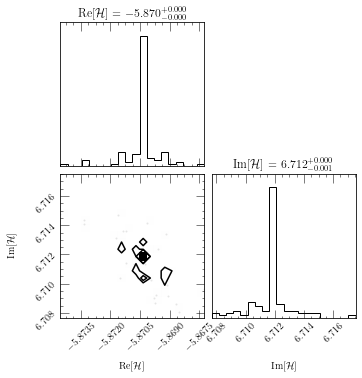

In [16]:
for good_kinematic_set in good_sets:
    print(f"[INFO]: Now analyzing kinematic set {good_kinematic_set}")

    observable_statistics = pd.read_csv(
        f"./hpc/version_{MAJOR_MINOR_NUMBER}/kinematic_set_{good_kinematic_set}/data/observable_preds_v{MAJOR_MINOR_NUMBER}.csv"
    )
    
    FIXED_BEAM_ENERGY = observable_statistics['k'].iloc[0]
    FIXED_T_VALUE = observable_statistics['t'].iloc[0]
    FIXED_X_BJORKEN = observable_statistics['xb'].iloc[0]
    FIXED_Q_SQUARED = observable_statistics['q_squared'].iloc[0]

    this_kinematic_set_title_string = (
        rf"$k = {observable_statistics['k'].iloc[0]:.2f}$ GeV, "
        rf"$x_B = {observable_statistics['xb'].iloc[0]:.2f}$, "
        rf"$t = {observable_statistics['t'].iloc[0]:.2f}$, "
        rf"$Q^2 = {observable_statistics['q_squared'].iloc[0]:.2f}$ GeV$^2$"
    )

    cff_real_h_km15 = observable_statistics['Re[H]'].iloc[0]
    cff_imag_h_km15 = observable_statistics['Im[H]'].iloc[0]
    cff_real_e_km15 = observable_statistics['Re[E]'].iloc[0]
    cff_imag_e_km15 = observable_statistics['Im[E]'].iloc[0]
    cff_real_ht_km15 = observable_statistics['Re[Ht]'].iloc[0]
    cff_imag_ht_km15 = observable_statistics['Im[Ht]'].iloc[0]
    cff_real_et_km15 = observable_statistics['Re[Et]'].iloc[0]
    cff_imag_et_km15 = observable_statistics['Im[Et]'].iloc[0]

    cff_h_km15 = complex(cff_real_h_km15, cff_imag_h_km15)
    cff_ht_km15 = complex(cff_real_e_km15, cff_imag_e_km15)
    cff_e_km15 = complex(cff_real_ht_km15, cff_imag_ht_km15)
    cff_et_km15 = complex(cff_real_et_km15, cff_imag_et_km15)

    km15_cff_string = (
        rf"$\mathcal{{H}}^{{\mathrm{{DNN}}}} = {cff_h_km15:.3f}$, "
        rf"$\mathcal{{E}} = {cff_e_km15:.3f}$, "
        rf"$\widetilde{{\mathcal{{H}}}} = {cff_ht_km15:.3f}$, "
        rf"$\widetilde{{\mathcal{{E}}}} = {cff_et_km15:.3f}$ "
    )

    # phi array
    phi_array_in_radians = observable_statistics['phi']

    # CROSS-SECTIONS:
    mean_cross_sections = observable_statistics['mean_xs']
    stddev_cross_sections = observable_statistics['std_xs']
    min_cross_sections = observable_statistics['min_xs']
    max_cross_sections = observable_statistics['max_xs']
    p10_cross_sections = observable_statistics['p10_xs']
    p20_cross_sections = observable_statistics['p20_xs']
    p30_cross_sections = observable_statistics['p30_xs']
    p40_cross_sections = observable_statistics['p40_xs']
    p60_cross_sections = observable_statistics['p60_xs']
    p70_cross_sections = observable_statistics['p70_xs']
    p80_cross_sections = observable_statistics['p80_xs']
    p90_cross_sections = observable_statistics['p90_xs']

    # BSA:
    mean_bsa = observable_statistics['mean_bsa']
    stddev_bsa = observable_statistics['std_bsa']
    min_bsa = observable_statistics['min_bsa']
    max_bsa = observable_statistics['max_bsa']
    p10_bsa = observable_statistics['p10_bsa']
    p20_bsa = observable_statistics['p20_bsa']
    p30_bsa = observable_statistics['p30_bsa']
    p40_bsa = observable_statistics['p40_bsa']
    p60_bsa = observable_statistics['p60_bsa']
    p70_bsa = observable_statistics['p70_bsa']
    p80_bsa = observable_statistics['p80_bsa']
    p90_bsa = observable_statistics['p90_bsa']

    xs_replica_avg_fig, xs_replica_avg_axis = plt.subplots(1, figsize = (7, 7))

    xs_replica_avg_axis.plot(
        phi_array_in_radians, mean_cross_sections,
        label = r'Replica Average', color = "blue", linewidth = 0.5, linestyle = 'dashed')
    xs_replica_avg_axis.fill_between(
        x = phi_array_in_radians, y1 = min_cross_sections, y2 = max_cross_sections,
        label = r'Min/Max Bound', color = "lightgray", alpha = 0.2)
    xs_replica_avg_axis.fill_between(
        x = phi_array_in_radians, y1 = p90_cross_sections, y2 = p10_cross_sections,
        label = r'10/90 \% Bound', color = "gray", alpha = 0.25)
    xs_replica_avg_axis.fill_between(
        x = phi_array_in_radians, y1 = p80_cross_sections, y2 = p20_cross_sections,
        label = r'20/80 \% Bound', color = "gray", alpha = 0.3)
    xs_replica_avg_axis.fill_between(
        x = phi_array_in_radians, y1 = p70_cross_sections, y2 = p30_cross_sections,
        label = r'30/70 \% Bound', color = "gray", alpha = 0.35)
    xs_replica_avg_axis.fill_between(
        x = phi_array_in_radians, y1 = p60_cross_sections, y2 = p40_cross_sections,
        label = r'40/60 \% Bound', color = "gray", alpha = 0.35)

    xs_replica_avg_axis.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
    xs_replica_avg_axis.set_ylabel(r"$d^{4}\sigma$ [nb / GeV$^{4}$]", fontsize = 16)
    xs_replica_avg_axis.set_title(
            rf"(Set {good_kinematic_set}), $d^{{4}}\sigma^{{UU}}$ vs. $\phi$, {this_kinematic_set_title_string}"
            "\n"
            f"(KM15): {km15_cff_string}", fontsize = 16)

    xs_replica_avg_axis.legend()

    for extension in ['png', 'eps']:
        xs_replica_avg_fig.savefig(
            f"./hpc/version_{MAJOR_MINOR_NUMBER}/kinematic_set_{good_kinematic_set}/plots/dnn_xsec_vs_phi_v{MAJOR_MINOR_NUMBER}.{extension}",
                facecolor = 'white',
                transparent = False)
        
    plt.close(xs_replica_avg_fig)

    bsa_replica_avg_fig, bsa_replica_avg_axis = plt.subplots(1, figsize = (7, 7))

    bsa_replica_avg_axis.plot(
        phi_array_in_radians, mean_bsa,
        label = r'Replica Average', color = "blue", linewidth = 0.5, linestyle = 'dashed')
    bsa_replica_avg_axis.fill_between(
        x = phi_array_in_radians, y1 = min_bsa, y2 = max_bsa,
        label = r'Min/Max Bound', color = "lightgray", alpha = 0.2)
    bsa_replica_avg_axis.fill_between(
        x = phi_array_in_radians, y1 = p90_bsa, y2 = p10_bsa,
        label = r'10/90 \% Bound', color = "gray", alpha = 0.25)
    bsa_replica_avg_axis.fill_between(
        x = phi_array_in_radians, y1 = p80_bsa, y2 = p20_bsa,
        label = r'20/80 \% Bound', color = "gray", alpha = 0.3)
    bsa_replica_avg_axis.fill_between(
        x = phi_array_in_radians, y1 = p70_bsa, y2 = p30_bsa,
        label = r'30/70 \% Bound', color = "gray", alpha = 0.35)
    bsa_replica_avg_axis.fill_between(
        x = phi_array_in_radians, y1 = p60_bsa, y2 = p40_bsa,
        label = r'40/60 \% Bound', color = "gray", alpha = 0.35)

    bsa_replica_avg_axis.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
    bsa_replica_avg_axis.set_ylabel(r"$d^{4}\sigma$ [nb / GeV$^{4}$]", fontsize = 16)
    bsa_replica_avg_axis.set_title(
            rf"(Set {good_kinematic_set}), BSA vs. $\phi$, {this_kinematic_set_title_string}"
            "\n"
            f"(KM15): {km15_cff_string}", fontsize = 16)

    bsa_replica_avg_axis.legend()

    for extension in ['png', 'eps']:
        bsa_replica_avg_fig.savefig(
            f"./hpc/version_{MAJOR_MINOR_NUMBER}/kinematic_set_{good_kinematic_set}/plots/dnn_bsa_vs_phi_v{MAJOR_MINOR_NUMBER}.{extension}",
                facecolor = 'white',
                transparent = False)
        
    plt.close(bsa_replica_avg_fig)

    del observable_statistics
    del xs_replica_avg_fig
    del xs_replica_avg_axis
    del bsa_replica_avg_fig
    del bsa_replica_avg_axis

    cff_statistics = pd.read_csv(
        f"./hpc/version_{MAJOR_MINOR_NUMBER}/kinematic_set_{good_kinematic_set}/data/cff_replica_average_preds_v{MAJOR_MINOR_NUMBER}.csv"
    )

    cff_h_real_pred_per_replica = cff_statistics['ReH_pred']
    cff_h_imag_pred_per_replica = cff_statistics['ImH_pred']

    cff_h_real_mean, cff_h_real_stddev = norm.fit(cff_h_real_pred_per_replica)
    cff_h_imag_mean, cff_h_imag_stddev = norm.fit(cff_h_imag_pred_per_replica)

    print(f"[INFO]: Re[H] mean of {cff_h_real_mean} and stdddev of {cff_h_real_stddev}")
    print(f"[INFO]: Im[H] mean of {cff_h_imag_mean} and stdddev of {cff_h_imag_stddev}")

    burner_x_values_cff_h_real = np.linspace(
        cff_h_real_mean - 4. * cff_h_real_stddev,
        cff_h_real_mean + 4. * cff_h_real_stddev,
        200)
    
    burner_x_values_cff_h_imag = np.linspace(
        cff_h_imag_mean - 4. * cff_h_imag_stddev,
        cff_h_imag_mean + 4. * cff_h_imag_stddev,
        200)

    cff_real_h_figure, cff_real_h_axis = plt.subplots(1, 1, figsize = (9, 7))

    cff_real_h_axis.hist(cff_h_real_pred_per_replica, bins = 30, alpha = 0.6, color = 'skyblue', edgecolor = 'black')
    cff_real_h_axis.plot(
        burner_x_values_cff_h_real, norm.pdf(burner_x_values_cff_h_real, cff_h_real_mean, cff_h_real_stddev), 
        color = "red", linestyle = "--", label = fr"Gaussian Fit: $\mu = {cff_h_real_mean:.3f}$, $\sigma = {cff_h_real_stddev:.3f}$")
    cff_real_h_axis.axvline(cff_real_h_km15, color = "green", linestyle = "-", linewidth = 2., label = f"KM15: {cff_real_h_km15:.3f}")

    cff_real_h_axis.set_ylabel("Frequency", rotation = 90.)
    cff_real_h_axis.set_xlabel(r"Re$[\mathcal{H}]$")
    cff_real_h_axis.set_title(
        rf"(Set {good_kinematic_set}) Re$[\mathcal{{H}}]$ Distribution ,{this_kinematic_set_title_string}"
        "\n"
        f"(KM15): {km15_cff_string}", fontsize = 16)

    cff_real_h_axis.legend()

    for extension in ['png', 'eps']:
        cff_real_h_figure.savefig(
            f"./hpc/version_{MAJOR_MINOR_NUMBER}/kinematic_set_{good_kinematic_set}/plots/cff_h_real_fits_v{MAJOR_MINOR_NUMBER}.{extension}",
            facecolor = 'white',
            transparent = False)

    plt.close(cff_real_h_figure)

    del cff_real_h_figure
    del cff_real_h_axis

    cff_imag_h_figure, cff_imag_h_axis = plt.subplots(1, 1, figsize = (9, 7))

    cff_imag_h_axis.hist(cff_h_imag_pred_per_replica, bins = 30, alpha = 0.6, color = 'skyblue', edgecolor = 'black')
    cff_imag_h_axis.plot(
        burner_x_values_cff_h_imag, norm.pdf(burner_x_values_cff_h_imag, cff_h_imag_mean, cff_h_imag_stddev), 
        color = "red", linestyle = "--", label = fr"Gaussian Fit: $\mu = {cff_h_imag_mean:.3f}$, $\sigma = {cff_h_imag_stddev:.3f}$")
    cff_imag_h_axis.axvline(cff_imag_h_km15, color = "green", linestyle = "-", linewidth = 2., label = f"KM15: {cff_imag_h_km15:.3f}")

    cff_imag_h_axis.set_ylabel("Frequency", rotation = 90.)
    cff_imag_h_axis.set_xlabel(r"Im$[\mathcal{H}]$")
    cff_imag_h_axis.set_title(
        rf"(Set {good_kinematic_set}) Im$[\mathcal{{H}}]$ Distribution ,{this_kinematic_set_title_string}"
        "\n"
        f"(KM15): {km15_cff_string}", fontsize = 16)

    cff_imag_h_axis.legend()

    for extension in ['png', 'eps']:
        cff_imag_h_figure.savefig(
            f"./hpc/version_{MAJOR_MINOR_NUMBER}/kinematic_set_{good_kinematic_set}/plots/cff_h_imag_fits_v{MAJOR_MINOR_NUMBER}.{extension}",
            facecolor = 'white',
            transparent = False)

    plt.close(cff_imag_h_figure)

    del cff_imag_h_figure
    del cff_imag_h_axis

    cff_samples_combined = np.vstack([cff_h_real_pred_per_replica, cff_h_imag_pred_per_replica]).T
    corner_fig = corner.corner(
        cff_samples_combined,
        labels = [r"Re$[\mathcal{H}]$", r"Im$[\mathcal{H}]$"],
        show_titles = True,
        title_fmt = ".3f",
        hist_kwargs = {'fc': 'skyblue', 'ec': 'black'}
    )
    for extension in ['png', 'eps']:
        corner_fig.savefig(
            f"./hpc/version_{MAJOR_MINOR_NUMBER}/kinematic_set_{good_kinematic_set}/plots/cff_h_corner_v{MAJOR_MINOR_NUMBER}.{extension}",
            facecolor = 'white',
            transparent = False)

    del cff_statistics
    del phi_array_in_radians
